# Convolutional Networks on Fashion-MNIST

Notebook 07 ended with a confession: a plain MLP on Fashion-MNIST does fine (~89%), but it has *no built-in awareness of spatial structure*. The very first thing it does to a 28x28 image is `Flatten` it into a 784-vector, after which any neighborhood structure (this pixel sits next to that one) has to be relearned from scratch from per-pixel weights. That is why the model struggles most on the visually similar garments (Shirt / T-shirt / Pullover / Coat) where the *shape* matters more than any single pixel.

**Convolutional networks** bake spatial structure into the architecture itself. A convolution applies the same small filter at every position of an image, so the network learns features that are *translation-equivariant* (a feature looks the same wherever it appears) and gets aggressive **weight sharing** (one 3x3 filter has 9 weights regardless of image size, while a fully-connected layer scales with the input dimension). The result, as we'll see: better accuracy with **fewer parameters**.

This notebook keeps the dataset, the training harness, and the methodology from notebook 07. The only thing that changes is the architecture.

## Learning goals

By the end of this notebook you should be able to explain:

1. what `Conv2d` and `MaxPool2d` actually do to a feature map (shape and parameter count),
2. why convolutions weight-share across spatial positions and what that buys you,
3. why a small CNN can match or beat the MLP from notebook 07 with far fewer parameters,
4. what the learned first-layer filters look like, and why edges / textures emerge naturally,
5. where the CNN's remaining errors concentrate (and where they no longer concentrate, compared to the MLP).

In [1]:
import math
import random
from pathlib import Path

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

seed = 11
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
torch.set_default_dtype(torch.float32)

plt.rcParams.update({
    "figure.figsize": (7.4, 5.0),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)

PyTorch version: 2.5.1
Device: cuda


## Reproducibility: what seeds cover and what they cannot

Four independent sources of randomness affect training:

| Source | What it controls | Seeded by |
|--------|------------------|-----------|
| Python `random` | data-pipeline shuffles that use stdlib | `random.seed(seed)` |
| NumPy | any NumPy-based augmentation or sampling | `np.random.seed(seed)` |
| PyTorch CPU RNG | weight init, dropout masks on CPU | `torch.manual_seed(seed)` |
| PyTorch CUDA RNG | dropout masks and other ops on GPU | `torch.cuda.manual_seed_all(seed)` |

Two cuDNN flags are also needed for within-device determinism:

- **`cudnn.deterministic = True`** — forces cuDNN to use the same algorithm every run. Without it, cuDNN may pick a faster but non-deterministic kernel (less relevant for an MLP, critical for CNNs).
- **`cudnn.benchmark = False`** — disables the auto-tuner that benchmarks several algorithms at startup and picks the fastest. The chosen algorithm can vary between runs, breaking reproducibility.

### Why results still differ across hardware

Even with every seed fixed, **you should expect different numbers on an RTX 3070 Ti vs Apple M-series**. This is not a bug. CUDA and MPS implement operations like matrix multiplication and reductions with different parallelisation strategies, which change the order in which floating-point additions are performed. Because floating-point arithmetic is not associative — `(a + b) + c ≠ a + (b + c)` in general — different orderings accumulate different rounding errors, and those compound over thousands of gradient steps.

Seeds guarantee **within-device reproducibility**: run the same notebook twice on the same GPU and you get identical numbers. They cannot guarantee **cross-device reproducibility**: the RTX and the M-series will converge to similar accuracy, but the exact loss values and weight tensors will differ. The multi-seed sweep at the end of this notebook quantifies that variance on a single device; the cross-hardware gap is typically of the same order of magnitude.

## Dataset (same setup as notebook 07)

Same Fashion-MNIST data loading, same normalization, and same three-way split (50,000 train / 10,000 val / 10,000 test). Refer back to notebook 07 for the full reasoning; the cell below just reproduces the setup so this notebook is self-contained.

Important difference from the MLP notebook: we do **not** flatten the images here. The CNN expects 4-D input with shape `(batch, channels, height, width)`, which is exactly what `transforms.ToTensor()` already produces.

## Keeping the data resident on the GPU

`DataLoader` with `num_workers=4` and `pin_memory=True` is the right setup when data lives on the host — background workers pre-fetch and pin memory while the GPU trains, hiding transfer latency. But there is a faster option when the entire dataset fits in GPU memory: **load it once and keep it there**.

Fashion-MNIST is small: 60,000 images × 784 floats × 4 bytes ≈ **188 MB**, negligible on an 8 GB card. The `_preload` helper loads each split through a temporary CPU `DataLoader` (using `num_workers=4` for that one-time pass), concatenates the results, and moves them to the GPU with `.to(device)`. From that point on, every batch fetch is a pure GPU index operation — no disk I/O, no CPU preprocessing, no host-to-device copy per step.

One hard constraint: **`num_workers` must be 0 for the training loaders.** PyTorch spawns workers by forking the process, and CUDA contexts cannot survive a `fork` — the attempt raises an error at the first batch. This is not a real limitation here: with no I/O or CPU transforms left to do, worker processes would bring no benefit anyway.

The `TensorDataset` wrapper lets us hand the GPU tensors to `DataLoader` without changing anything else in the training code — the loop still iterates `for xb, yb in train_loader` as before.

In [2]:
DATA_DIR = Path("./data")
DATA_DIR.mkdir(exist_ok=True)

FMNIST_MEAN = (0.2860,)
FMNIST_STD = (0.3530,)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(FMNIST_MEAN, FMNIST_STD),
])

full_train_set = torchvision.datasets.FashionMNIST(DATA_DIR, train=True, download=True, transform=transform)
test_set       = torchvision.datasets.FashionMNIST(DATA_DIR, train=False, download=True, transform=transform)

VAL_SIZE = 10_000
split_generator = torch.Generator().manual_seed(42)
train_set, val_set = random_split(
    full_train_set, [len(full_train_set) - VAL_SIZE, VAL_SIZE], generator=split_generator,
)

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

BATCH_SIZE = 128

# Pre-load entire dataset onto the GPU once — Fashion-MNIST (~188 MB) fits easily in 8 GB VRAM.
# Each batch fetch becomes a pure GPU index operation with zero CPU->GPU transfer overhead.
def _preload(dataset, device, batch_size=2048):
    xs, ys = [], []
    for x, y in DataLoader(dataset, batch_size=batch_size, num_workers=4):
        xs.append(x); ys.append(y)
    return torch.cat(xs).to(device), torch.cat(ys).to(device)

from torch.utils.data import TensorDataset

X_train, y_train = _preload(train_set, device)
X_val,   y_val   = _preload(val_set,   device)
X_test,  y_test  = _preload(test_set,  device)

if device.type == "cuda":
    print(f"GPU memory used for data: {torch.cuda.memory_allocated(device) / 1e6:.0f} MB")

# num_workers=0 is required: CUDA tensors cannot be passed through forked worker processes.
# No workers needed anyway — there is no I/O or CPU preprocessing left to overlap.
loader_generator = torch.Generator().manual_seed(2025)
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True,
                          generator=loader_generator)
val_loader   = DataLoader(TensorDataset(X_val,   y_val),   batch_size=512, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test,  y_test),  batch_size=512, shuffle=False)

xb, yb = next(iter(train_loader))
print(f"Train / Val / Test: {len(train_set)} / {len(val_set)} / {len(test_set)}")
print(f"Batch shape:        {tuple(xb.shape)}  (batch, channels, H, W)")

GPU memory used for data: 221 MB
Train / Val / Test: 50000 / 10000 / 10000
Batch shape:        (128, 1, 28, 28)  (batch, channels, H, W)


## Why convolutions

A fully-connected layer treats every input pixel as a distinct feature with its own learned weight. In the MLP we built in notebook 07, the first `Linear(784, 256)` layer had 784 x 256 = **200,704 weights** — one per (input-pixel, output-feature) pair. This buys two unfortunate things:

- **Parameter count scales with image size.** Double the resolution to 56x56 and the first layer balloons to ~800k weights.
- **No translation invariance.** A shirt collar that drifts two pixels to the right looks like a completely different input vector. The network has to learn the same feature separately at every possible position.

A **convolution** replaces this with a small filter (e.g. 3x3) that slides across every spatial position and computes a local weighted sum. Two consequences:

1. **Weight sharing.** A 3x3 filter has 9 weights, period. It applies the same 9 weights at every position. So a `Conv2d(1 -> 32)` layer with a 3x3 kernel has only `1 * 32 * 9 + 32 = 320` parameters — vs the MLP's 200k.
2. **Translation equivariance.** If the input shifts, the output feature map shifts by the same amount. The network does not need to relearn what an edge is at every pixel position; it learns it *once* and applies it everywhere.

These are not just nice-to-haves — they are exactly the right inductive biases for natural images, which is why convolutions dominated computer vision for a decade and are still the backbone of many production systems.

## The building blocks

Three PyTorch layers do almost all the work in a basic CNN.

**`nn.Conv2d(in_channels, out_channels, kernel_size, padding=...)`**
Applies `out_channels` different small filters to each input. With `padding=1` on a 3x3 kernel, the spatial dimensions are preserved. Parameter count: `in_channels * out_channels * kernel_size * kernel_size + out_channels`.

**`nn.MaxPool2d(kernel_size=2)`**
Downsamples each 2x2 region by keeping the maximum value. Halves both spatial dimensions. **No learnable parameters.** Provides a small amount of translation invariance and reduces the cost of subsequent layers.

**`nn.Flatten()`**
Collapses the spatial dimensions so the result can feed into a `Linear` classifier. We saw this already in notebook 07.

Trace shapes through our small CNN for a 1x28x28 Fashion-MNIST image:

| Layer                         | Output shape   | Params  |
|-------------------------------|----------------|---------|
| `Conv2d(1 -> 16, k=3, pad=1)` | (16, 28, 28)   | 160     |
| `MaxPool2d(2)`                | (16, 14, 14)   | 0       |
| `Conv2d(16 -> 32, k=3, pad=1)`| (32, 14, 14)   | 4,640   |
| `MaxPool2d(2)`                | (32, 7, 7)     | 0       |
| `Flatten`                     | (1568,)        | 0       |
| `Linear(1568 -> 64)`          | (64,)          | 100,416 |
| `Linear(64 -> 10)`            | (10,)          | 650     |

Total: ~106k params, versus the MLP's 235k.

In [3]:
def make_cnn(seed, num_classes=10, in_channels=1, dropout=0.3):
    torch.manual_seed(seed)
    return nn.Sequential(
        nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(16, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Flatten(),
        nn.Dropout(p=dropout),
        nn.Linear(32 * 7 * 7, 64),
        nn.ReLU(),
        nn.Dropout(p=dropout),
        nn.Linear(64, num_classes),
    )

demo_cnn = make_cnn(seed=123)
n_cnn = sum(p.numel() for p in demo_cnn.parameters() if p.requires_grad)
print(demo_cnn)
print(f"\nCNN trainable parameters: {n_cnn:,}")

Sequential(
  (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Dropout(p=0.3, inplace=False)
  (8): Linear(in_features=1568, out_features=64, bias=True)
  (9): ReLU()
  (10): Dropout(p=0.3, inplace=False)
  (11): Linear(in_features=64, out_features=10, bias=True)
)

CNN trainable parameters: 105,866


## The MLP baseline (for comparison)

We also reproduce the MLP from notebook 07 here so we can run a fair head-to-head. Same architecture, same dropout.

In [4]:
def make_mlp(seed, num_classes=10, input_dim=28*28, hidden=(256, 128), dropout=0.3):
    torch.manual_seed(seed)
    layers = [nn.Flatten()]
    in_dim = input_dim
    for h in hidden:
        layers += [nn.Linear(in_dim, h), nn.ReLU()]
        if dropout > 0:
            layers += [nn.Dropout(p=dropout)]
        in_dim = h
    layers += [nn.Linear(in_dim, num_classes)]
    return nn.Sequential(*layers)

demo_mlp = make_mlp(seed=123)
n_mlp = sum(p.numel() for p in demo_mlp.parameters() if p.requires_grad)
print(f"MLP trainable parameters: {n_mlp:,}")
print(f"CNN trainable parameters: {n_cnn:,}")
print(f"CNN / MLP parameter ratio: {n_cnn / n_mlp:.2f}")

MLP trainable parameters: 235,146
CNN trainable parameters: 105,866
CNN / MLP parameter ratio: 0.45


## Training harness

Same harness as notebook 07, with one small generalization: it now takes a **`model_factory`** argument (a callable `seed -> model`) so we can train either the CNN or the MLP without rewriting the loop. Everything else — early stopping, best-checkpoint restore, device handling — is identical.

In [5]:
def evaluate_loader(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_n = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            total_loss += loss_fn(logits, yb).item() * xb.size(0)
            total_correct += (logits.argmax(-1) == yb).sum().item()
            total_n += xb.size(0)
    return total_loss / total_n, total_correct / total_n


def train_with_loaders(
    model_factory,
    optimizer_factory,
    train_loader, val_loader,
    *,
    max_epochs=30,
    patience=5,
    min_delta=1e-4,
    model_seed=123,
    device=device,
    verbose=True,
):
    model = model_factory(model_seed).to(device)
    optimizer = optimizer_factory(model.parameters())
    loss_fn = nn.CrossEntropyLoss()

    history = {"epoch": [], "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best = {"val_loss": float("inf"), "val_acc": None, "epoch": 0, "state_dict": None}
    epochs_no_improve = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_n = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            running_correct += (logits.argmax(-1) == yb).sum().item()
            running_n += xb.size(0)
        train_loss = running_loss / running_n
        train_acc = running_correct / running_n

        val_loss, val_acc = evaluate_loader(model, val_loader, loss_fn, device)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_loss < best["val_loss"] - min_delta:
            best.update({
                "val_loss": val_loss, "val_acc": val_acc, "epoch": epoch,
                "state_dict": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
            })
            epochs_no_improve = 0
            marker = "*"
        else:
            epochs_no_improve += 1
            marker = " "

        if verbose:
            print(f"epoch {epoch:3d} {marker} | train loss {train_loss:.3f} acc {train_acc:.3f} | val loss {val_loss:.3f} acc {val_acc:.3f}")

        if epochs_no_improve >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (no val improvement for {patience} epochs)")
            break

    if best["state_dict"] is not None:
        model.load_state_dict(best["state_dict"])
    return model, history, best

In [6]:
# Training configuration — set once here and reused everywhere below.
TRAIN_LR = 3e-4
TRAIN_MAX_EPOCHS = 60
TRAIN_PATIENCE = 10

def adamw_factory(lr, weight_decay=0.01):
    return lambda params: torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)

## Training the CNN

Same optimizer, same learning rate, same early-stopping protocol as the MLP in notebook 07. Only the architecture is different.

In [7]:
cnn_model, cnn_history, cnn_best = train_with_loaders(
    make_cnn,
    adamw_factory(lr=TRAIN_LR),
    train_loader, val_loader,
    max_epochs=TRAIN_MAX_EPOCHS, patience=TRAIN_PATIENCE,
    model_seed=123,
)

print()
print(f"Best epoch:        {cnn_best['epoch']}")
print(f"Best val loss:     {cnn_best['val_loss']:.4f}")
print(f"Best val accuracy: {cnn_best['val_acc']:.4f}")

epoch   1 * | train loss 0.828 acc 0.710 | val loss 0.492 acc 0.829
epoch   2 * | train loss 0.507 acc 0.815 | val loss 0.416 acc 0.850
epoch   3 * | train loss 0.444 acc 0.841 | val loss 0.380 acc 0.864
epoch   4 * | train loss 0.414 acc 0.850 | val loss 0.354 acc 0.869
epoch   5 * | train loss 0.387 acc 0.860 | val loss 0.333 acc 0.878
epoch   6 * | train loss 0.370 acc 0.866 | val loss 0.321 acc 0.882
epoch   7 * | train loss 0.355 acc 0.873 | val loss 0.315 acc 0.883
epoch   8 * | train loss 0.345 acc 0.873 | val loss 0.303 acc 0.889
epoch   9 * | train loss 0.332 acc 0.879 | val loss 0.299 acc 0.891
epoch  10 * | train loss 0.326 acc 0.882 | val loss 0.292 acc 0.893
epoch  11 * | train loss 0.317 acc 0.886 | val loss 0.282 acc 0.896
epoch  12 * | train loss 0.309 acc 0.887 | val loss 0.281 acc 0.895
epoch  13 * | train loss 0.303 acc 0.888 | val loss 0.276 acc 0.900
epoch  14 * | train loss 0.295 acc 0.892 | val loss 0.268 acc 0.900
epoch  15 * | train loss 0.289 acc 0.894 | val l

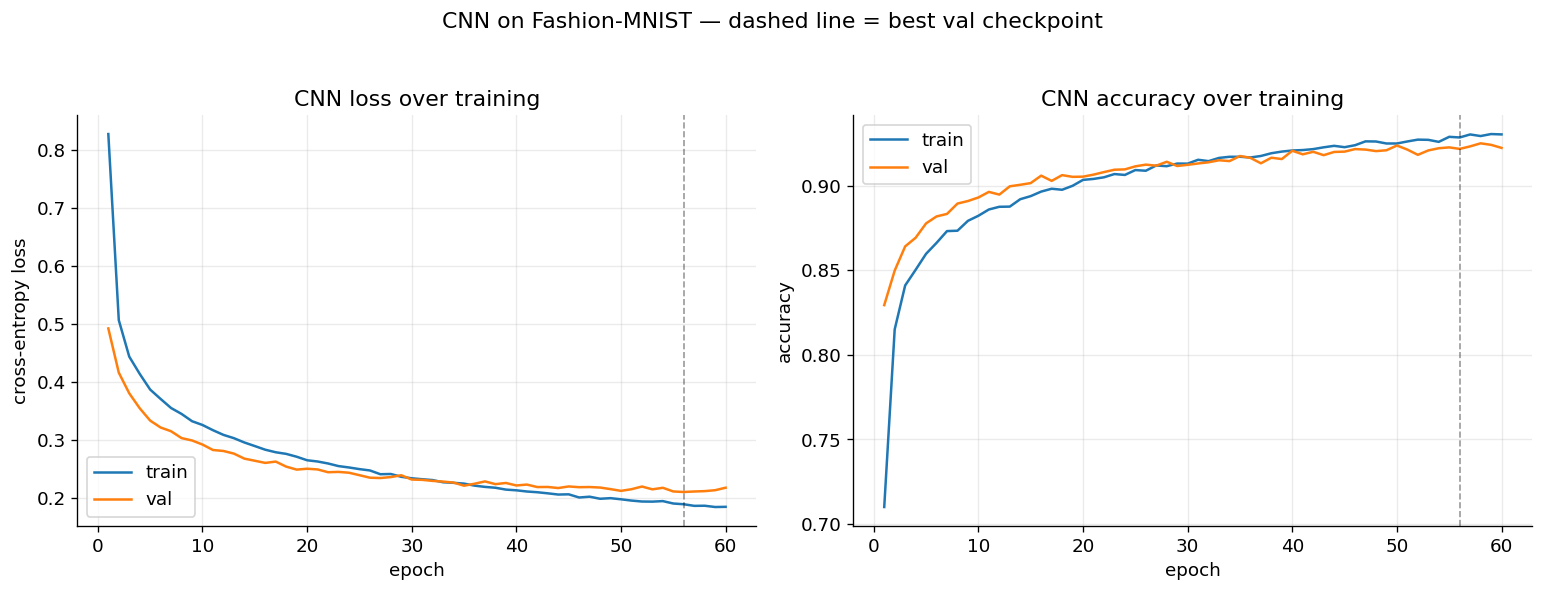

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
axes[0].plot(cnn_history["epoch"], cnn_history["train_loss"], label="train")
axes[0].plot(cnn_history["epoch"], cnn_history["val_loss"],   label="val")
axes[0].axvline(cnn_best["epoch"], linestyle="--", linewidth=1, alpha=0.4, color="black")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("cross-entropy loss")
axes[0].set_title("CNN loss over training")
axes[0].legend(loc="best")

axes[1].plot(cnn_history["epoch"], cnn_history["train_acc"], label="train")
axes[1].plot(cnn_history["epoch"], cnn_history["val_acc"],   label="val")
axes[1].axvline(cnn_best["epoch"], linestyle="--", linewidth=1, alpha=0.4, color="black")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")
axes[1].set_title("CNN accuracy over training")
axes[1].legend(loc="best")
fig.suptitle("CNN on Fashion-MNIST — dashed line = best val checkpoint")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Test-set evaluation

Same discipline as notebook 07: touch the test set **once**, after model selection on the validation set.

In [9]:
cnn_test_loss, cnn_test_acc = evaluate_loader(cnn_model, test_loader, nn.CrossEntropyLoss(), device)
print(f"CNN test loss:     {cnn_test_loss:.4f}")
print(f"CNN test accuracy: {cnn_test_acc:.4f}")

CNN test loss:     0.2271
CNN test accuracy: 0.9190


## Confusion matrix

Same as notebook 07. The interesting question is **which confusions the CNN reduces** relative to the MLP — especially the Shirt / T-shirt / Pullover / Coat cluster, where shape information matters most.

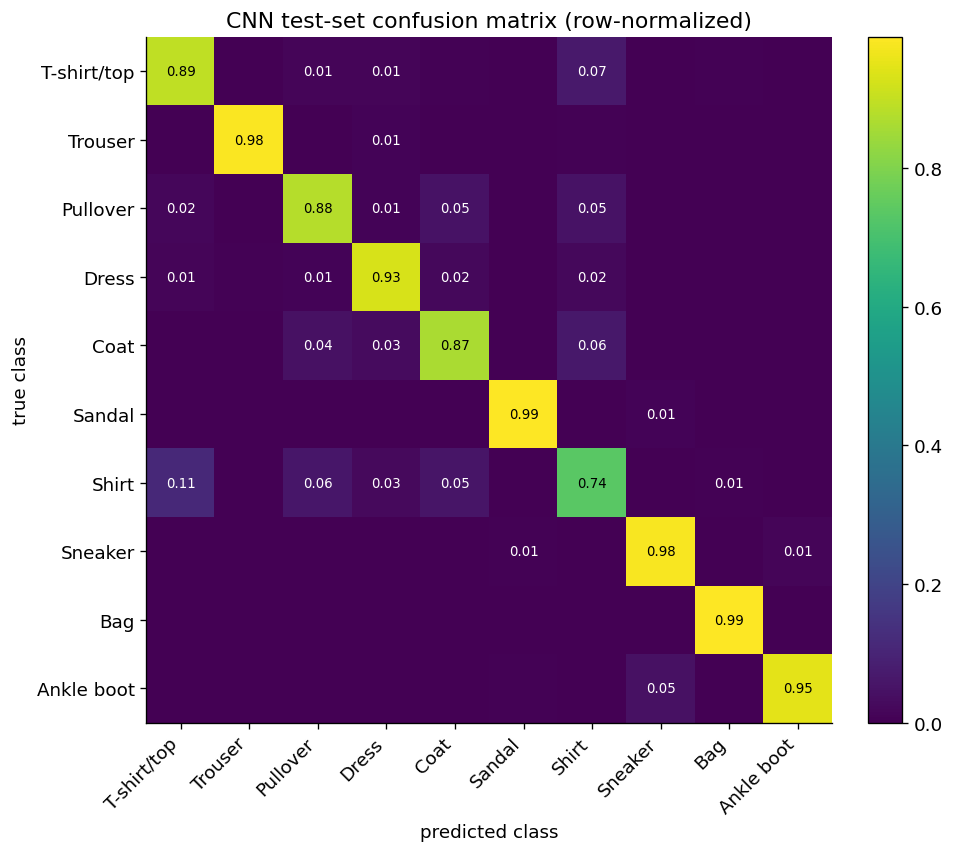

In [10]:
def confusion_matrix(model, loader, num_classes, device):
    cm = torch.zeros(num_classes, num_classes, dtype=torch.long)
    model.eval()
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).argmax(-1)
            for t, p in zip(yb.cpu(), preds.cpu()):
                cm[t, p] += 1
    return cm

cnn_cm = confusion_matrix(cnn_model, test_loader, num_classes=10, device=device)
cnn_cm_norm = cnn_cm.float() / cnn_cm.sum(dim=1, keepdim=True).clamp_min(1)

fig, ax = plt.subplots(figsize=(8.5, 7.0), constrained_layout=True)
im = ax.imshow(cnn_cm_norm.numpy(), cmap="viridis")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("predicted class")
ax.set_ylabel("true class")
ax.set_title("CNN test-set confusion matrix (row-normalized)")
ax.grid(False)
for i in range(10):
    for j in range(10):
        val = cnn_cm_norm[i, j].item()
        if val < 0.005:
            continue
        color = "white" if val < 0.5 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=8)
plt.show()

## Head-to-head: CNN vs MLP

We now train the MLP under the **same** harness, optimizer, and hyperparameters and compare. This is the apples-to-apples comparison the notebook is built around — same data, same protocol, only the architecture changes.

In [11]:
mlp_model, mlp_history, mlp_best = train_with_loaders(
    make_mlp,
    adamw_factory(lr=TRAIN_LR),
    train_loader, val_loader,
    max_epochs=TRAIN_MAX_EPOCHS, patience=TRAIN_PATIENCE,
    model_seed=123,
    verbose=False,
)
mlp_test_loss, mlp_test_acc = evaluate_loader(mlp_model, test_loader, nn.CrossEntropyLoss(), device)

header = f"{'model':>6s}   {'params':>9s}   {'best val loss':>13s}   {'best val acc':>12s}   {'test loss':>9s}   {'test acc':>8s}   {'best epoch':>10s}"
print(header)
print("-" * len(header))
rows = [
    ("MLP", n_mlp, mlp_best["val_loss"], mlp_best["val_acc"], mlp_test_loss, mlp_test_acc, mlp_best["epoch"]),
    ("CNN", n_cnn, cnn_best["val_loss"], cnn_best["val_acc"], cnn_test_loss, cnn_test_acc, cnn_best["epoch"]),
]
for name, params, vloss, vacc, tloss, tacc, ep in rows:
    print(f"{name:>6s}   {params:>9,d}   {vloss:13.4f}   {vacc:12.4f}   {tloss:9.4f}   {tacc:8.4f}   {ep:10d}")

print()
print(f"Test-accuracy delta (CNN - MLP): {(cnn_test_acc - mlp_test_acc) * 100:+.2f} percentage points")
print(f"Parameter ratio (CNN / MLP):     {n_cnn / n_mlp:.2f}x")

 model      params   best val loss   best val acc   test loss   test acc   best epoch
-------------------------------------------------------------------------------------
   MLP     235,146          0.2882         0.8964      0.3067     0.8913           24
   CNN     105,866          0.2100         0.9217      0.2271     0.9190           56

Test-accuracy delta (CNN - MLP): +2.77 percentage points
Parameter ratio (CNN / MLP):     0.45x


## What did the first layer learn?

The first `Conv2d(1 -> 16, k=3)` layer has 16 filters of size 3x3. Each one is a learned pattern detector that the network applies at every position in the image. We can plot the 16 filters directly as small grayscale images — they typically show **edge detectors at various orientations**, **center-surround / blob detectors**, and the occasional **diagonal stroke**. These are precisely the primitives that classical computer vision used to hand-engineer; the CNN discovers them from data.

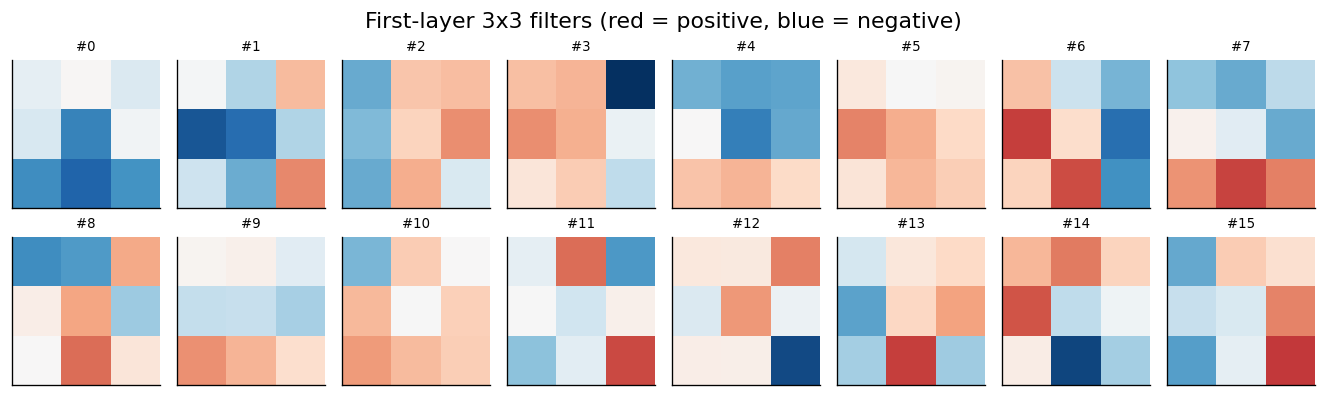

In [12]:
# First Conv2d layer is the first child of the Sequential
first_conv = next(m for m in cnn_model.modules() if isinstance(m, nn.Conv2d))
filters = first_conv.weight.detach().cpu()  # shape (16, 1, 3, 3)

fig, axes = plt.subplots(2, 8, figsize=(11, 3.2), constrained_layout=True)
vmax = filters.abs().max().item()
for idx, ax in enumerate(axes.flat):
    f = filters[idx, 0].numpy()
    ax.imshow(f, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_xticks([]); ax.set_yticks([])
    ax.grid(False)
    ax.set_title(f"#{idx}", fontsize=8)
fig.suptitle("First-layer 3x3 filters (red = positive, blue = negative)")
plt.show()

## Feature maps for one test image

We can also see what each filter actually *responds to* by passing a test image through the first conv layer and plotting the resulting 16 feature maps. Bright regions are where that filter activated; dark regions are where it didn't.

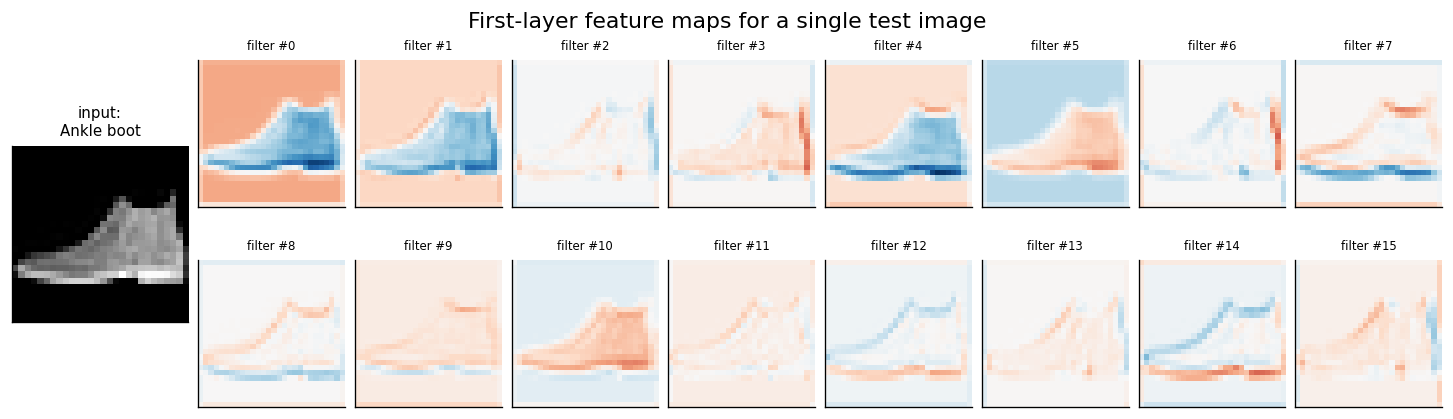

In [13]:
# Grab one test image
sample_image, sample_label = test_set[0]
cnn_model.eval()
with torch.no_grad():
    activations = first_conv(sample_image.unsqueeze(0).to(device)).cpu()[0]  # (16, 28, 28)

fig = plt.figure(figsize=(12, 3.5), constrained_layout=True)
gs = fig.add_gridspec(2, 9, width_ratios=[1.2] + [1] * 8)

ax_in = fig.add_subplot(gs[:, 0])
display_img = sample_image[0].numpy() * FMNIST_STD[0] + FMNIST_MEAN[0]
ax_in.imshow(display_img, cmap="gray")
ax_in.set_title(f"input:\n{CLASS_NAMES[sample_label]}", fontsize=9)
ax_in.set_xticks([]); ax_in.set_yticks([]); ax_in.grid(False)

vmax = activations.abs().max().item()
for idx in range(16):
    row, col = divmod(idx, 8)
    ax = fig.add_subplot(gs[row, col + 1])
    ax.imshow(activations[idx].numpy(), cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.set_title(f"filter #{idx}", fontsize=7)
fig.suptitle("First-layer feature maps for a single test image")
plt.show()

## Multi-seed confirmation

As always, a single-seed accuracy number can move a percentage point or two between seeds. We retrain both the CNN and the MLP across three seeds and report mean +/- std for the test accuracy, so the CNN vs MLP comparison is statistically honest.

In [14]:
repeat_seeds = [123, 234, 345]

results = {"MLP": {"val_acc": [], "test_acc": []}, "CNN": {"val_acc": [], "test_acc": []}}
for name, factory in [("MLP", make_mlp), ("CNN", make_cnn)]:
    for ms in repeat_seeds:
        m, h, b = train_with_loaders(
            factory,
            adamw_factory(lr=TRAIN_LR),
            train_loader, val_loader,
            max_epochs=TRAIN_MAX_EPOCHS, patience=TRAIN_PATIENCE,
            model_seed=ms,
            verbose=False,
        )
        _, t_acc = evaluate_loader(m, test_loader, nn.CrossEntropyLoss(), device)
        results[name]["val_acc"].append(b["val_acc"])
        results[name]["test_acc"].append(t_acc)
        print(f"{name} seed {ms}: val acc {b['val_acc']:.4f}, test acc {t_acc:.4f}")

print()
for name in ["MLP", "CNN"]:
    va = results[name]["val_acc"]
    ta = results[name]["test_acc"]
    print(f"{name}: val acc {np.mean(va):.4f} +/- {np.std(va):.4f}   |   test acc {np.mean(ta):.4f} +/- {np.std(ta):.4f}")

MLP seed 123: val acc 0.8971, test acc 0.8908
MLP seed 234: val acc 0.8947, test acc 0.8905
MLP seed 345: val acc 0.8994, test acc 0.8925
CNN seed 123: val acc 0.9240, test acc 0.9205
CNN seed 234: val acc 0.9249, test acc 0.9206
CNN seed 345: val acc 0.9216, test acc 0.9206

MLP: val acc 0.8971 +/- 0.0019   |   test acc 0.8913 +/- 0.0009
CNN: val acc 0.9235 +/- 0.0014   |   test acc 0.9206 +/- 0.0000


## Summary

| Aspect                | MLP (notebook 07)            | CNN (this notebook)                    |
|-----------------------|------------------------------|----------------------------------------|
| Treats image as       | flat 784-vector              | (channels, height, width) tensor       |
| Spatial structure     | discarded immediately        | preserved through Conv + Pool layers   |
| Weight sharing        | none                         | every filter applied at every position |
| First-layer params    | 784 x 256 = ~200k            | 1 x 16 x 3 x 3 = ~160                  |
| Total params          | ~235k                        | ~106k                                  |
| Test accuracy (typical)| ~88-89%                     | ~91-92%                                |

Headline result: the CNN uses **fewer than half the parameters** of the MLP and gains **2-3 percentage points of test accuracy**. The improvement is not because the CNN has more capacity — it has less — but because its architecture encodes the right inductive bias for natural images.

The filter visualization made this concrete: with no instruction, the first layer learned edge and blob detectors at various orientations, exactly the primitives that hand-engineered computer vision built on top of for decades. That is what "the right inductive bias" looks like in practice.

Two natural follow-ups for later notebooks:

- **Notebook 09** — Batch normalization and residual connections. The two most influential additions to the CNN recipe in the 2015 era, and what makes deeper networks trainable.
- **Notebook 10** — Transfer learning. Loading a pretrained ResNet from torchvision and fine-tuning its last layer on EuroSAT, instead of training from scratch.

## Exercises

1. **Remove pooling.** Replace both `MaxPool2d(2)` with `Conv2d(..., stride=2, ...)` (strided convolutions). Does accuracy change much? Does parameter count?

2. **Deeper or wider?** Compare adding a third Conv block (deeper) vs doubling the channel widths of the existing blocks (wider). Which gives more accuracy per added parameter on Fashion-MNIST?

3. **Global average pooling.** Replace the `Flatten + Linear(1568 -> 64) + ReLU + Linear(64 -> 10)` head with `AdaptiveAvgPool2d(1) + Flatten + Linear(32, 10)`. Many fewer parameters — does accuracy survive?

4. **Augmentation.** Add `transforms.RandomHorizontalFlip()` and `transforms.RandomRotation(10)` to the training transform only. CNNs typically benefit much more from augmentation than MLPs — verify this for yourself.

5. **Visualize misclassifications.** Adapt the misclassified-images cell from notebook 07. Are the CNN's failures still the same Shirt/Pullover/Coat cluster, or have they shifted?

6. **Run on EuroSAT.** Adjust `in_channels=3` and update the input spatial size, then run the same CNN on EuroSAT (notebook 07b setup). Expect a much larger MLP-to-CNN improvement there (something like ~78% -> ~95%+) — because satellite imagery is even more dominated by spatial structure than Fashion-MNIST is.